In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from keras.models import Model
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from keras.layers import (
    Input,
    Dense,
    Flatten,
    Conv1D,
    MaxPooling1D
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

In [11]:
# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Research/Diabetes/diabetes_012_health_indicators_BRFSS2015.csv')

print("Dataset Shape:", df.shape)

Dataset Shape: (253680, 22)


In [12]:
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [13]:
# ==============================
# 3. Features & Target
# ==============================
X = df.drop(['Diabetes_012', 'AnyHealthcare'], axis=1)
y = df['Diabetes_012']

# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [14]:
# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(pd.Series(y_train).value_counts())

Diabetes_012
0.0    149592
2.0     24742
1.0      3242
Name: count, dtype: int64


In [15]:
# Reshape data for RNN [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [16]:
# Build SimpleRNN model
model = Sequential()

# SimpleRNN layer
model.add(SimpleRNN(
    32,
    activation='tanh',
    input_shape=(X_train.shape[1], 1)
))

# Output Layer
output_layer = Dense(3, activation='softmax')


# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Early stopping (monitor accuracy instead of loss)
early_stopping = EarlyStopping(
    monitor='accuracy',
    patience=10,
    restore_best_weights=True
)

# Start timing
start_time = tf.timestamp()

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# End timing
end_time = tf.timestamp()

# Convert to float
total_time = float(end_time - start_time)
average_time_per_epoch = total_time / len(history.history['loss'])

# Print results
print(f'Total Training Time: {total_time:.2f} seconds')
print(f'Average Time per Epoch: {average_time_per_epoch:.2f} seconds')

Epoch 1/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.8238 - loss: 0.8900
Epoch 2/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.8424 - loss: 0.7076
Epoch 3/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.8422 - loss: 0.6699
Epoch 4/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.8390 - loss: 0.6820
Epoch 5/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.8279 - loss: 0.6141
Epoch 6/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.8424 - loss: 0.6322
Epoch 7/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.8421 - loss: 0.5607
Epoch 8/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.8424 - loss: 0.5793
Epoch 9/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.8424 - loss: 0.6130
Epoch 10/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.8411 - loss: 0.5930
Epoch 11/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.8424 - loss: 0.5122
Epoch 12/20
5550/55

In [18]:
# ==============================
# 8. Evaluate Model
# ==============================
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.8424130082130432


In [19]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [20]:
# ==============================
# 8. Prediction
# ==============================
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [21]:
# ==============================
# 9. Metrics
# ==============================
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Weighted Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")


Confusion Matrix:
[[64111     0     0]
 [ 1389     0     0]
 [10604     0     0]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      1.00      0.91     64111
         1.0       0.00      0.00      0.00      1389
         2.0       0.00      0.00      0.00     10604

    accuracy                           0.84     76104
   macro avg       0.28      0.33      0.30     76104
weighted avg       0.71      0.84      0.77     76104


Weighted Precision: 0.7097
Weighted Recall: 0.8424
Weighted F1-Score: 0.7704


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

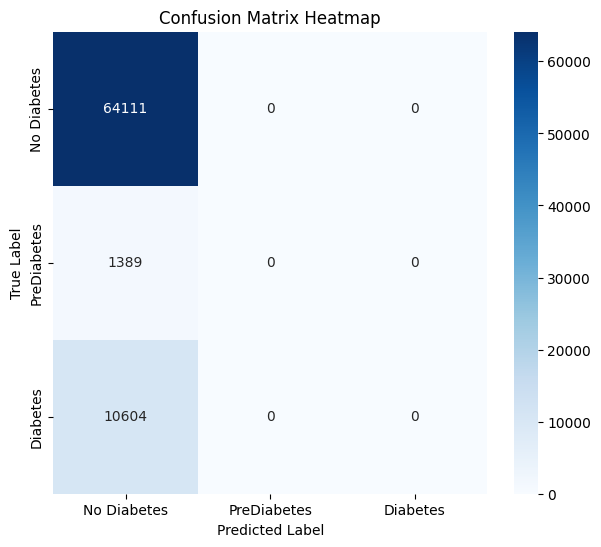

In [22]:
# ==============================
# 10. Confusion Matrix Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

classes = ['No Diabetes', 'PreDiabetes', 'Diabetes']

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()